# Формирование временных рядов

In [1]:
import polars as pl
import pandas as pd

In [2]:
FILE_PATH = "ШЧ_2_corr.xlsx"

# 1. Определение количества листов
xls = pd.ExcelFile(FILE_PATH, engine="openpyxl")
sheet_names = xls.sheet_names
n_sheets = len(sheet_names)
print(f"Количество листов: {n_sheets}")
print(f"Названия листов: {sheet_names}")
# Объявляем список,
dfs = []
for sheet in sheet_names:    
    df = pl.read_excel(FILE_PATH, sheet_name=sheet)    
    # способ добавить столбец в Polars (pl.lit(sheet) — создание литерала (константы), .alias("Год_листа") — присвоение имени)
    df = df.with_columns(
        pl.lit(sheet).alias("Год_листа")
    )
    dfs.append(df)
    # объединяем все датафреймы в один (диагонально - на случай разных наборов колонок)
result = pl.concat(dfs, how="diagonal_relaxed")


Could not determine dtype for column 10, falling back to string


Количество листов: 6
Названия листов: ['2019', '2018', '2017', '2016', '2015', '2014']


Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 10, falling back to string


In [3]:
# Сделаем копию нашего массива. ВОПРОС: для чего?
df = result.clone()
# Приводим колонку "Дата осмотра" к типу datetime, если она строковая
df = df.with_columns( 
    pl.col("Дата осмотра").str.strptime(pl.Datetime, strict=False, format=None)
    if df.schema["Дата осмотра"] == pl.Utf8
    else pl.col("Дата осмотра")
)

# ===========================================================
# 5.1 Извлечение признаков из даты
# ===========================================================
df = df.with_columns([
    pl.col("Дата осмотра").dt.week().alias("Номер_недели"),      # номер недели в году
    pl.col("Дата осмотра").dt.ordinal_day().alias("Номер_дня"),  # номер дня в году
    pl.col("Дата осмотра").dt.month().alias("Номер_месяца"),     # номер месяца
    pl.col("Дата осмотра").dt.year().alias("Год"),                # год
])

print("\nПример новых признаков даты:")
print(df.select(["Дата осмотра", "Год", "Номер_месяца", "Номер_недели", "Номер_дня"]).head(10))


Пример новых признаков даты:
shape: (10, 5)
┌──────────────┬──────┬──────────────┬──────────────┬───────────┐
│ Дата осмотра ┆ Год  ┆ Номер_месяца ┆ Номер_недели ┆ Номер_дня │
│ ---          ┆ ---  ┆ ---          ┆ ---          ┆ ---       │
│ date         ┆ i32  ┆ i8           ┆ i8           ┆ i16       │
╞══════════════╪══════╪══════════════╪══════════════╪═══════════╡
│ 2019-04-03   ┆ 2019 ┆ 4            ┆ 14           ┆ 93        │
│ 2019-04-03   ┆ 2019 ┆ 4            ┆ 14           ┆ 93        │
│ 2019-04-03   ┆ 2019 ┆ 4            ┆ 14           ┆ 93        │
│ 2019-04-03   ┆ 2019 ┆ 4            ┆ 14           ┆ 93        │
│ 2019-04-03   ┆ 2019 ┆ 4            ┆ 14           ┆ 93        │
│ 2019-04-03   ┆ 2019 ┆ 4            ┆ 14           ┆ 93        │
│ 2019-04-03   ┆ 2019 ┆ 4            ┆ 14           ┆ 93        │
│ 2019-04-03   ┆ 2019 ┆ 4            ┆ 14           ┆ 93        │
│ 2019-04-03   ┆ 2019 ┆ 4            ┆ 14           ┆ 93        │
│ 2019-04-03   ┆ 2019 ┆ 4      

Ответ: чтобы result остался как был и к нему можно было вернуться без повторного чтения excel.

In [4]:
df[:1]

__UNNAMED__0,Дата осмотра,Осмотр проводил,"Станция, перегон","Объекты, количество отступлений",Классификация (Группа),Классификация (Вид),Примечание,Крайний срок,Статус,Причина,Дата устранения,Год_листа,Номер_недели,Номер_дня,Номер_месяца,Год
i64,date,str,str,str,str,str,str,date,str,str,date,str,i8,i16,i8,i32
0,2019-04-03,"""Сотрудник_0""","""станция_0""","""327""","""группа_0""","""вид_0""","""Стрелка №39 устранить люфт дли…",2019-04-13,"""ЗАКРЫТО""",null,2019-04-11,"""2019""",14,93,4,2019


In [5]:
# Соберем данные для нашего временного ряда
df_agg = (
    df.group_by(["Станция, перегон", "Номер_дня"])
    .agg(pl.col("Дата осмотра").count().alias("Количество инцидентов"))
    .sort(["Станция, перегон", "Номер_дня"])
)
df_agg

"Станция, перегон",Номер_дня,Количество инцидентов
str,i16,u32
"""станция_0""",1,11
"""станция_0""",2,7
"""станция_0""",13,23
"""станция_0""",15,11
"""станция_0""",17,11
…,…,…
"""станция_99""",268,5
"""станция_99""",286,9
"""станция_99""",318,1


In [6]:
# Создаем новый датафрейм
min_day = 1
max_day = 365
pl.DataFrame({"Номер дня": range(min_day, max_day + 1)})

Номер дня
i64
1
2
3
4
5
…
361
362
363


In [7]:
# Выровняем временной ряд
min_day = 1
max_day = 366

df_aligned = (
    df_agg
    .select("Станция, перегон")
    .unique()
    .join(
        pl.DataFrame({"Номер_дня": range(min_day, max_day + 1)}),
        how="cross",
    )
    .join(df_agg, on=["Станция, перегон", "Номер_дня"], how="left")
    .sort(["Станция, перегон", "Номер_дня"])
    .with_columns(
        pl.col("Количество инцидентов")
          .fill_null(0) #заполняем пропущенные значения 0
        # .fill_null(strategy="forward")  # вариант B: последнее известное
        # .interpolate()                  # вариант C: линейная интер
    )
)
df_aligned[:14]

"Станция, перегон",Номер_дня,Количество инцидентов
str,i64,u32
"""станция_0""",1,11
"""станция_0""",2,7
"""станция_0""",3,0
"""станция_0""",4,0
"""станция_0""",5,0
…,…,…
"""станция_0""",10,0
"""станция_0""",11,0
"""станция_0""",12,0


In [8]:
# Добавляем столбец, характеризующий прирост, накопленный итог (важно! расчет ведется в рамках каждой станции)
df_aligned = (
    df_aligned
    .with_columns(
        pl.col("Количество инцидентов")
          .fill_null(0)
          .fill_nan(0)
    )
    .with_columns(
        pl.col("Количество инцидентов")
          .diff()
          .over("Станция, перегон") # это нужно для того чтобы начать расчет с каждой станции с 0
          .alias("Прирост инцидентов")
    )
    .with_columns(
        pl.col("Количество инцидентов")
          .cum_sum()
          .over("Станция, перегон") # это нужно для того чтобы начать расчет с каждой станции с 0
          .alias("Нарощенный итог")
    ))
df_aligned

"Станция, перегон",Номер_дня,Количество инцидентов,Прирост инцидентов,Нарощенный итог
str,i64,u32,i64,u32
"""станция_0""",1,11,null,11
"""станция_0""",2,7,-4,18
"""станция_0""",3,0,-7,18
"""станция_0""",4,0,0,18
"""станция_0""",5,0,0,18
…,…,…,…,…
"""станция_99""",362,0,0,276
"""станция_99""",363,0,0,276
"""станция_99""",364,0,0,276


In [9]:
pip install tslearn

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/401.7 kB ? eta -:--:--
   --- ----------------------------------- 41.0/401.7 kB 991.0 kB/s eta 0:00:01
   ------------ --------------------------- 122.9/401.7 kB 1.4 MB/s eta 0:00:01
   ------------------ --------------------- 184.3/401.7 kB 1.6 MB/s eta 0:00:01
   -------------------------- ------------- 266.2/401.7 kB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 317.4/401.7 kB 1.5 MB/s eta 0:00:01
   ---------------------------------- ----- 348.2/401.7 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  399.4/401.7 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 401.7/401.7 kB 1.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
    --------------------------------------- 0.1/2.8 MB 1.7 MB/s eta 0:00:02
   - -------------------------------------- 0.1/2.8 MB 1.2 MB/s eta 0:00:03
  

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orange3 3.37.0 requires scikit-learn<1.5.0,>=1.3.0, but you have scikit-learn 1.9.1 which is incompatible.


In [10]:
# Ищем ответ на вопрос: динамика отказов на каких станциях похожа друг на друга?

import numpy as np
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans

c:\Users\Student\AppData\Local\Programs\Orange\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [11]:
METRICS = [
    "Количество инцидентов",
    "Прирост инцидентов",
    "Нарощенный итог",
]

In [12]:
df_clean = (
    df_aligned
    .sort(["Станция, перегон", "Номер_дня"])
    .fill_null(0)
)

df_grouped = (
    df_aligned
    .sort(["Станция, перегон", "Номер_дня"])
    .fill_null(0)
    .group_by("Станция, перегон", maintain_order=True)
    .agg([
        pl.col("Номер_дня").alias("days"),
        *[pl.col(m).implode().alias(m) for m in METRICS]  # ← implode()
    ])
)
df_grouped


"Станция, перегон",days,Количество инцидентов,Прирост инцидентов,Нарощенный итог
str,list[i64],list[u32],list[i64],list[u32]
"""станция_0""","[1, 2, … 366]","[11, 7, … 0]","[0, -4, … 0]","[11, 18, … 5755]"
"""станция_1""","[1, 2, … 366]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 200]"
"""станция_10""","[1, 2, … 366]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 309]"
"""станция_100""","[1, 2, … 366]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 517]"
"""станция_101""","[1, 2, … 366]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 61]"
…,…,…,…,…
"""станция_95""","[1, 2, … 366]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 142]"
"""станция_96""","[1, 2, … 366]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 507]"
"""станция_97""","[1, 2, … 366]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 130]"


In [13]:
stations_list = df_grouped["Станция, перегон"].to_list()
X_ts = np.array([
    np.column_stack([row[m] for m in METRICS])
    for row in df_grouped.iter_rows(named=True)
])

print(f"Форма массива: {X_ts.shape}")

Форма массива: (118, 366, 3)


In [14]:
# 1. Нормализация (важно для DTW, чтобы амплитуда не доминировала над формой)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_ts)
X_scaled

array([[[-1.49705714e-01,  7.00003859e-04, -1.60004081e+00],
        [-2.76466364e-01, -9.24641461e-02, -1.59609279e+00],
        [-4.98297503e-01, -1.62337259e-01, -1.59609279e+00],
        ...,
        [-2.76466364e-01,  9.38641538e-02,  1.63959502e+00],
        [-4.98297503e-01, -1.62337259e-01,  1.63959502e+00],
        [-4.98297503e-01,  7.00003859e-04,  1.63959502e+00]],

       [[-1.43942865e-01,  0.00000000e+00, -1.53650152e+00],
        [-1.43942865e-01,  0.00000000e+00, -1.53650152e+00],
        [-1.43942865e-01,  0.00000000e+00, -1.53650152e+00],
        ...,
        [-1.43942865e-01,  0.00000000e+00,  1.15827557e+00],
        [-1.43942865e-01,  0.00000000e+00,  1.15827557e+00],
        [-1.43942865e-01,  0.00000000e+00,  1.15827557e+00]],

       [[-2.00365975e-01,  0.00000000e+00, -1.75998197e+00],
        [-2.00365975e-01,  0.00000000e+00, -1.75998197e+00],
        [-2.00365975e-01,  0.00000000e+00, -1.75998197e+00],
        ...,
        [-2.00365975e-01,  0.00000000e+00,

In [15]:
n_days = X_scaled.shape[1]
sakoe_chiba_radius = max(1, int(n_days * 0.15))

n_clusters = 6
print(f"Запуск DTW кластеризации (окно={sakoe_chiba_radius})...")

# ✅ НОВОЕ: параметры DTW передаются напрямую, а не через dtw_params={}
km_dtw = TimeSeriesKMeans(
    n_clusters=n_clusters,
    metric="dtw",
    max_iter=50,
    random_state=42,
    n_init=5,
) # Гиперпараметр модели.

labels = km_dtw.fit_predict(X_scaled)

# ШАГ 3: Возврат результатов в Polars

df_clusters = pl.DataFrame({
    "Станция, перегон": stations_list,
    "cluster_dtw": labels
})

4

Запуск DTW кластеризации (окно=54)...


4

In [16]:
df_clusters['cluster_dtw'].value_counts()

cluster_dtw,count
i64,u32
3,19
5,21
1,16
2,22
0,29
4,11


In [17]:
df_clusters.filter(pl.col('cluster_dtw')==0)

"Станция, перегон",cluster_dtw
str,i64
"""станция_0""",0
"""станция_1""",0
"""станция_10""",0
"""станция_113""",0
"""станция_114""",0
…,…
"""станция_84""",0
"""станция_85""",0
"""станция_91""",0


In [18]:
# Задание! на график временные ряды станций кластера 0 (или другого). Не используйте GTP, ищите в контенте лекций.
# Посчитайте основые характеристики временных рядов кластера. Подумайте что это за характеристики. 

Станций в кластере 0: 29


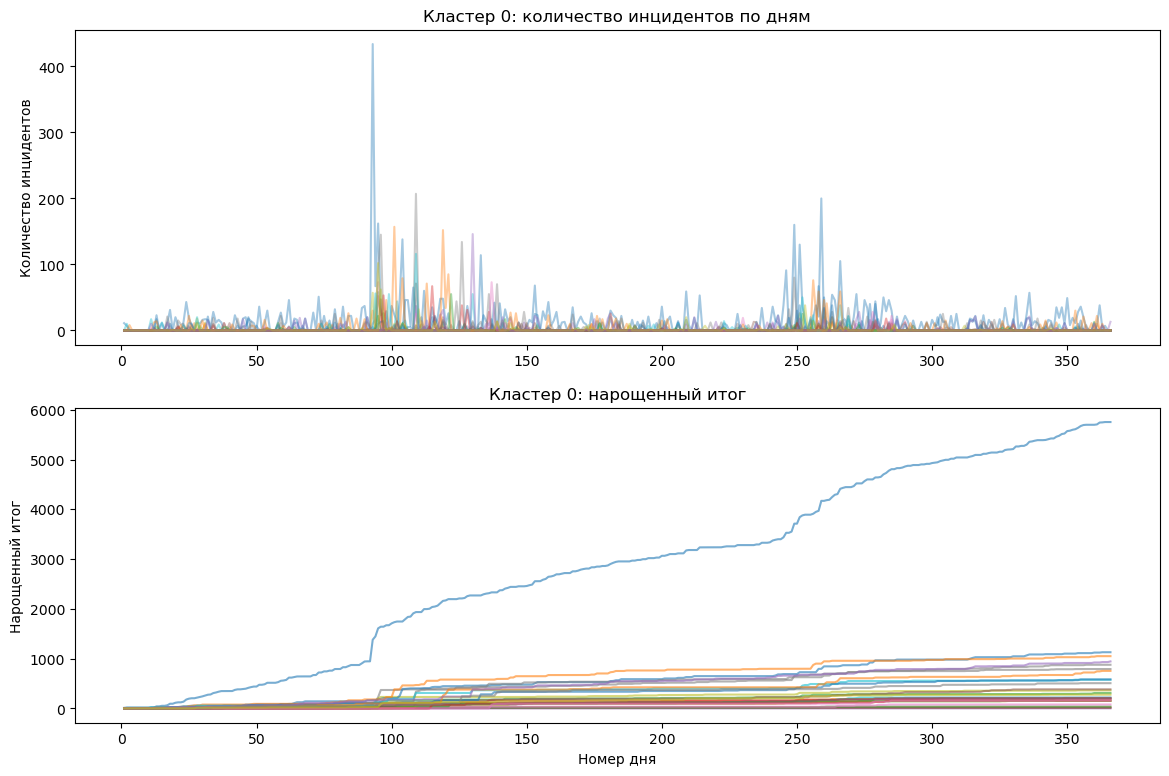

In [19]:
# берём станции из кластера 0
stations_0 = df_clusters.filter(pl.col('cluster_dtw')==0)["Станция, перегон"].to_list()
df_cluster_0 = df_aligned.filter(pl.col("Станция, перегон").is_in(stations_0))
print("Станций в кластере 0:", len(stations_0))

fig, ax = plt.subplots(2, 1, figsize=(14, 9))
for station in stations_0:
    d = df_cluster_0.filter(pl.col("Станция, перегон") == station)
    ax[0].plot(d["Номер_дня"], d["Количество инцидентов"], alpha=0.4)
    ax[1].plot(d["Номер_дня"], d["Нарощенный итог"], alpha=0.6)
ax[0].set_title("Кластер 0: количество инцидентов по дням")
ax[0].set_ylabel("Количество инцидентов")
ax[1].set_title("Кластер 0: нарощенный итог")
ax[1].set_ylabel("Нарощенный итог")
ax[1].set_xlabel("Номер дня")
plt.show()

In [20]:
# характеристики рядов по каждой станции кластера 0
df_cluster_0.group_by("Станция, перегон").agg([
    pl.col("Количество инцидентов").sum().alias("Сумма"),
    pl.col("Количество инцидентов").mean().alias("Среднее"),
    pl.col("Количество инцидентов").median().alias("Медиана"),
    pl.col("Количество инцидентов").std().alias("Ст_отклонение"),
    pl.col("Количество инцидентов").max().alias("Максимум"),
    (pl.col("Количество инцидентов") > 0).sum().alias("Дней_с_инцидентами"),
]).sort("Сумма", descending=True)

"Станция, перегон",Сумма,Среднее,Медиана,Ст_отклонение,Максимум,Дней_с_инцидентами
str,u32,f64,f64,f64,u32,u32
"""станция_0""",5755,15.724044,9.0,31.598731,434,222
"""станция_33""",1129,3.084699,0.0,10.596248,138,65
"""станция_36""",1050,2.868852,0.0,12.014797,157,53
"""станция_84""",944,2.579235,0.0,9.372826,146,66
"""станция_17""",877,2.396175,0.0,10.525579,145,63
…,…,…,…,…,…,…
"""станция_54""",78,0.213115,0.0,1.796021,25,10
"""станция_37""",36,0.098361,0.0,0.818383,11,7
"""станция_113""",20,0.054645,0.0,0.74191,11,2


In [21]:
# те же характеристики по всем кластерам, чтобы было с чем сравнить кластер 0
df_aligned.join(df_clusters, on="Станция, перегон").group_by("cluster_dtw").agg([
    pl.col("Станция, перегон").n_unique().alias("Станций"),
    pl.col("Количество инцидентов").mean().alias("Среднее"),
    pl.col("Количество инцидентов").std().alias("Ст_отклонение"),
    pl.col("Количество инцидентов").max().alias("Максимум"),
    (pl.col("Количество инцидентов") > 0).mean().alias("Доля_дней_с_инцидентами"),
]).sort("cluster_dtw")

cluster_dtw,Станций,Среднее,Ст_отклонение,Максимум,Доля_дней_с_инцидентами
i64,u32,f64,f64,u32,f64
0,29,1.534765,9.087443,434,0.095063
1,16,0.971653,5.750065,110,0.072746
2,22,1.398038,4.980914,86,0.136364
3,19,0.927092,6.313312,199,0.07262
4,11,0.399404,2.693436,61,0.045703
5,21,0.611371,4.927849,204,0.055816


Характеристики: сумма, среднее, медиана, стандартное отклонение, максимум и сколько дней были инциденты. По сути это уровень, разброс, пики и как часто что-то происходит.

По графику у станций кластера похожая форма: почти весь год инцидентов мало, а весной (90–130 день) и в сентябре (250–270 день) резкие скачки, похоже на осмотры. При этом по количеству станции очень разные (на станции_0 5755, на станции_116 всего 8), потому что ряды нормализовали, и кластеры собираются по форме, а не по количеству.

In [22]:
# Задание 2. По аналогии с кодом выше проведите агрегацию по станциям, по каждой станции нужны характеристики временных рядов, а не многомерные временнные ряды
# целевой массив
                # Признак_1  Признак_2 Признак_3 Признак_4 Признак_5
# Станция_0
# Станция_1
# Станция_2

In [23]:
# по каждой станции считаем характеристики её временного ряда
df_features = (
    df_aligned
    .group_by("Станция, перегон", maintain_order=True)
    .agg([
        pl.col("Количество инцидентов").sum().alias("Всего_инцидентов"),
        pl.col("Количество инцидентов").mean().alias("Среднее_в_день"),
        pl.col("Количество инцидентов").std().alias("Ст_отклонение"),
        pl.col("Количество инцидентов").max().alias("Максимум_в_день"),
        (pl.col("Количество инцидентов") > 0).mean().alias("Доля_дней_с_инцидентами"),
        pl.col("Прирост инцидентов").abs().mean().alias("Средний_прирост_по_модулю"),
    ])
)
print(f"Форма массива: {df_features.shape}")
df_features

Форма массива: (118, 7)


"Станция, перегон",Всего_инцидентов,Среднее_в_день,Ст_отклонение,Максимум_в_день,Доля_дней_с_инцидентами,Средний_прирост_по_модулю
str,u32,f64,f64,u32,f64,f64
"""станция_0""",5755,15.724044,31.598731,434,0.606557,21.076712
"""станция_1""",200,0.546448,3.801481,52,0.032787,0.931507
"""станция_10""",309,0.844262,4.219369,58,0.103825,1.435616
"""станция_100""",517,1.412568,4.479084,40,0.169399,2.372603
"""станция_101""",61,0.166667,1.133347,12,0.027322,0.323288
…,…,…,…,…,…,…
"""станция_95""",142,0.387978,2.223725,24,0.065574,0.673973
"""станция_96""",507,1.385246,8.531116,134,0.084699,2.531507
"""станция_97""",130,0.355191,3.126478,49,0.054645,0.69589


Ответ: получилась таблица, где одна строка это одна станция, а в столбцах характеристики ее ряда. Ее можно сразу подавать в KMeans без DTW.